In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov




/tmp/ipykernel_943919/667692420.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2000_4000_num_chains_32.pkl','rb'))
# df.keys()
sig8 = df['sigma8']
# nchains = 80
nchains = 64
sig8_rs = sig8.reshape(nchains,-1)
# print(sig8_rs.shape)
from numpyro.diagnostics import autocorrelation, autocovariance

acorr = autocorrelation(sig8_rs, axis=1)
ind_del = []
for ji in range(acorr.shape[0]):
    if np.std(acorr[ji,100:]) > 0.075:
        ind_del.append(ji)

print(len(ind_del), ind_del)



31 [3, 6, 9, 11, 14, 17, 18, 19, 20, 22, 23, 26, 27, 28, 30, 31, 33, 36, 37, 40, 42, 43, 44, 45, 46, 49, 50, 52, 54, 56, 60]


In [3]:
samps = []
keys = []
for key in df:
    # if ('base' not in key) and ('decentered' not in key):
        # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
        if key not in ['RUN_SETTINGS', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')



samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
if len(ind_del) > 0:
    samps_sel = np.delete(samps_sel, ind_del, axis=0)
else:
    samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
print(samps.shape, samps_sel.shape)


(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(132000, 44) (33, 4000, 44)


In [4]:
# samps.shape
nsamp_tot = samps.shape[0]
indsel = np.sort(np.random.randint(0, nsamp_tot, 32))
indsel



array([  2386,  11519,  32393,  32871,  33514,  35024,  36354,  43241,
        44035,  52923,  56151,  59276,  62017,  62915,  65827,  68988,
        78661,  78714,  87685,  89102,  90189,  96338,  97328, 106364,
       114073, 114389, 116873, 117263, 123257, 126446, 126832, 127810])

In [5]:
import warnings
warnings.filterwarnings("ignore")


In [41]:
import numpy as np
from math import factorial
def savitzky_golay(y, window_size, order, deriv=0, rate=1):    
    try:
        window_size = np.abs((window_size))
        order = np.abs((order))
    except ValueError:
        raise ValueError("window_size and order have to be of type int")
    if window_size % 2 != 1 or window_size < 1:
        raise TypeError("window_size size must be a positive odd number")
    if window_size < order + 2:
        raise TypeError("window_size is too small for the polynomials order")
    order_range = range(order+1)
    half_window = (window_size -1) // 2
    # precompute coefficients
    b = np.asmatrix([[k**i for i in order_range] for k in range(-half_window, half_window+1)])
    m = np.linalg.pinv(b).A[deriv] * rate**deriv * factorial(deriv)
    # pad the signal at the extremes with
    # values taken from the signal itself
    firstvals = y[0] - np.abs( y[1:half_window+1][::-1] - y[0] )
    lastvals = y[-1] + np.abs(y[-half_window-1:-1][::-1] - y[-1])
    y = np.concatenate((firstvals, y, lastvals))
    return np.convolve( m[::-1], y, mode='valid')




In [65]:
from tqdm import tqdm

# ind_post = keys.index('potential_energy')
# post = -1.* samps[:,ind_post]

# map_ind = np.where(post == post.max())[0][0]

# Y_model_all_samp = []
Pmm_ratio_all_samp = []

for map_ind in tqdm(indsel):
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        # print(key, samps[map_ind, jk])
        saved_bestfit[key] = samps[map_ind, jk]
    
    # potential_energy -4916.635080802822
    import yaml
    import pathlib
    curr_path = pathlib.Path().absolute()
    abs_path_data = os.path.abspath(curr_path / "../../data/") 
    abs_path_src = os.path.abspath(curr_path / "../../src/") 
    abs_path_results = os.path.abspath(curr_path / "../../results/") 
    abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    
    from deepmerge import always_merger
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    
    # saved_bestift
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 4
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']

    halo_params_dict['rmax'] = 12.0
    halo_params_dict['nr'] = 128
    halo_params_dict['nk'] = 96
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    Pmm_ratio_all_samp.append(savitzky_golay(ratio, 19, 3))




100%|██████████| 32/32 [05:09<00:00,  9.66s/it]


In [56]:
map_ind = indsel[3]
saved_bestfit = {}
for jk, key in enumerate(keys):
    # print(key, samps[map_ind, jk])
    saved_bestfit[key] = samps[map_ind, jk]

# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)


# saved_bestift
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)


for key in saved_bestfit.keys():
    if key in list(sim_params_dict.keys()):
        sim_params_dict[key] = float(saved_bestfit[key])
    if key in list(sim_params_dict['cosmo'].keys()):
        sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
        if key == 'h':
            sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
    if key in list(other_params_dict.keys()):
        other_params_dict[key] = float(saved_bestfit[key])
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']


halo_params_dict['rmax'] = 8.0
halo_params_dict['nr'] = 196
halo_params_dict['nk'] = 96
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)



In [57]:
halo_params_dict 



{'rmin': 0.005,
 'rmax': 8.0,
 'nr': 196,
 'zmin': 0.01,
 'zmax': 1.6,
 'nz': 22,
 'lg10_Mmin': 11.5,
 'lg10_Mmax': 15.5,
 'nM': 22,
 'kmin': 0.0001,
 'kmax': 150.0,
 'nk': 96,
 'ellmin': 11.29462706,
 'ellmax': 8971.6413594,
 'nell': 30,
 'mdef_Delta': 200,
 'conc_model': 'Duffy08',
 'hmf_model': 'T10',
 'do_corr_2h_mm': True,
 'ell_array': Array([1.12946271e+01, 1.42190930e+01, 1.79007776e+01, 2.25357438e+01,
        2.83708205e+01, 3.57167470e+01, 4.49647204e+01, 5.66072292e+01,
        7.12642794e+01, 8.97164123e+01, 1.12946271e+02, 1.42190931e+02,
        1.79007777e+02, 2.25357439e+02, 2.83708207e+02, 3.57167472e+02,
        4.49647207e+02, 5.66072296e+02, 7.12642799e+02, 8.97164130e+02,
        1.12946272e+03, 1.42190932e+03, 1.79007778e+03, 2.25357441e+03,
        2.83708209e+03, 3.57167475e+03, 4.49647210e+03, 5.66072300e+03,
        7.12642804e+03, 8.97164136e+03, 1.12946273e+04, 1.42190933e+04,
        1.79007779e+04, 2.25357443e+04, 2.83708211e+04, 3.57167477e+04,
        4

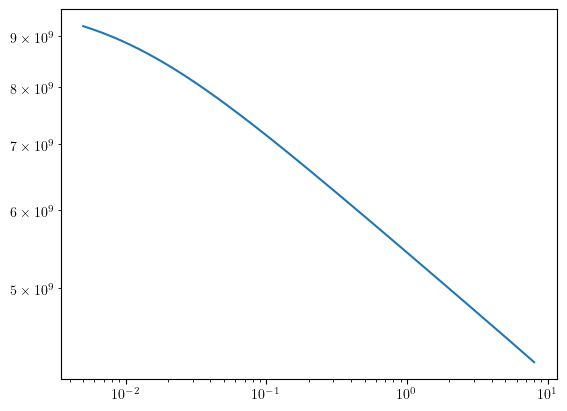

In [22]:
# Pkz_test.M_array
pl.figure()
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pmm_dmb_tot_mat[:,indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pmm_dmb_1h_kz_mat[:,indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pmm_dmb_2h_kz_mat[:,indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.bm_dmb_kz_mat[:,indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.bm_dmb_2h[:,indz])
# pl.plot(Pkz_test.r_array, Pkz_test.rho_dmb_mat[:,indz, 3])
pl.plot(Pkz_test.r_array, Pkz_test.rho_gas_mat[:,indz, 3])
# pl.plot(Pkz_test.r_array, Pkz_test.rho_clm_mat[:,indz, 3])
# pl.plot(Pkz_test.kPk_array, Pkz_test.bm_largescales_2h_mat_lt_Mmin[indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pmm_nfw_tot_mat[:,indz], ls='--')
pl.xscale('log')
pl.yscale('log')
# pl.xlim(0.1, 1)


(0.1, 1)

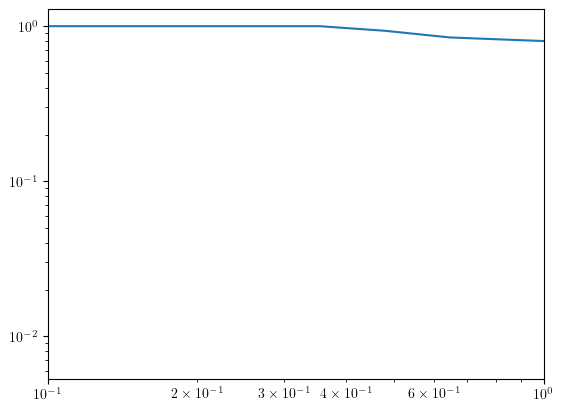

In [23]:
indz = 0

pl.figure()
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pmm_dmb_tot_mat[:,indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pmm_dmb_1h_kz_mat[:,indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pmm_dmb_2h_kz_mat[:,indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.bm_dmb_kz_mat[:,indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.bm_dmb_2h[:,indz])
pl.plot(Pkz_test.kPk_array, Pkz_test.uk_dmb[:,indz, 9])
# pl.plot(Pkz_test.kPk_array, Pkz_test.bm_largescales_2h_mat_lt_Mmin[indz])
# pl.plot(Pkz_test.kPk_array, Pkz_test.Pmm_nfw_tot_mat[:,indz], ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlim(0.1, 1)
# pl.ylim(3e2, 6e3)


(0.5, 1.1)

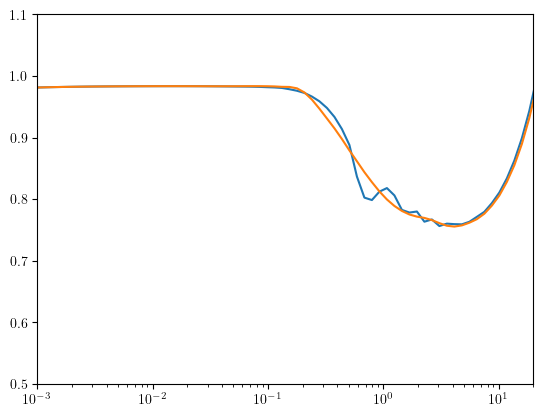

In [64]:
# jp = 10
ratio = Pkz_test.Pmm_dmb_tot_mat[:,indz]/Pkz_test.Pmm_nfw_tot_mat[:,indz]
# yhat = savitzky_golay(y, 51, 3)
indz = 1
pl.figure()
pl.plot(Pkz_test.kPk_array, ratio)
pl.plot(Pkz_test.kPk_array, savitzky_golay(ratio, 19, 3))
pl.xscale('log')
pl.xlim(1e-3, 20)
pl.ylim(0.5, 1.1)





In [67]:
# Y_model_all_samp.shape
Pmm_ratio_all_samp = np.array(Pmm_ratio_all_samp)
# Pmm_ratio_all_samp_mean = np.mean(Pmm_ratio_all_samp, axis=0)
# Pmm_ratio_all_samp_std = np.std(Pmm_ratio_all_samp, axis=0)
Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)




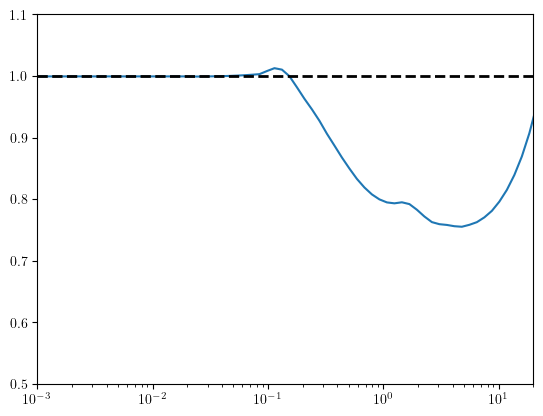

In [68]:
ji = 3
pl.figure()
pl.plot(Pkz_test.kPk_array, Pmm_ratio_all_samp[ji, :])
pl.xscale('log')
pl.xlim(1e-3, 20)
pl.ylim(0.5, 1.1)
pl.axhline(1.0, ls='--', lw=2, color='k')


In [27]:
# ji


3

In [23]:
# pl.figure()
# # for ji in range(len(indsel)):
#     # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
# pl.fill_between(Pkz_test.kPk_array, Pmm_ratio_all_samp_mean-Pmm_ratio_all_samp_std, Pmm_ratio_all_samp_mean+Pmm_ratio_all_samp_std, alpha=0.2)
# # pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
# # pl.plot(M_array, 1.25e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
# pl.xscale('log')
# pl.xlim(1e-3, 20)
# pl.ylim(0.5, 1.1)
# pl.axhline(1.0, ls='--', lw=2, color='k')
# # pl.yscale('log')
# pl.xlabel(r'$k$ ($h$/Mpc)', fontsize=20)
# pl.ylabel(r'$P_{\rm dmb}(k)/P_{\rm nfw}(k)$', fontsize=20)
# # pl.xlim(1e13, 1.2e15)
# # pl.ylim(5e-4, 2e1)
# # pl.legend(fontsize=18)
# pl.tick_params(axis='both', which='major', labelsize=16)
# pl.tick_params(axis='both', which='minor', labelsize=16)
# # pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
# pl.show()



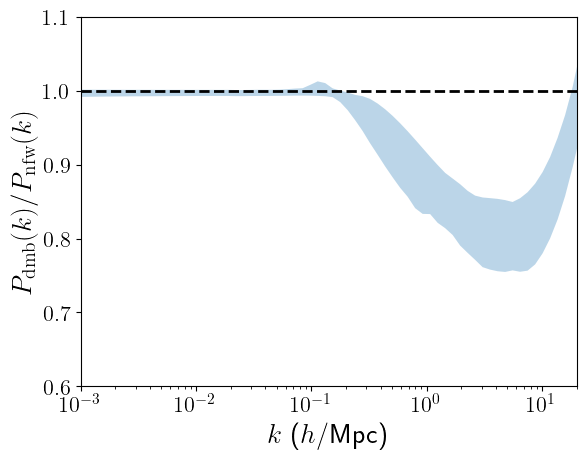

In [71]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
pl.fill_between(Pkz_test.kPk_array, Pmin, Pmax, alpha=0.3)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
# pl.plot(M_array, 1.25e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.xlim(1e-3, 20)
pl.ylim(0.6, 1.1)
pl.axhline(1.0, ls='--', lw=2, color='k')
# pl.yscale('log')
pl.xlabel(r'$k$ ($h$/Mpc)', fontsize=20)
pl.ylabel(r'$P_{\rm dmb}(k)/P_{\rm nfw}(k)$', fontsize=20)
# pl.xlim(1e13, 1.2e15)
# pl.ylim(5e-4, 2e1)
# pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()



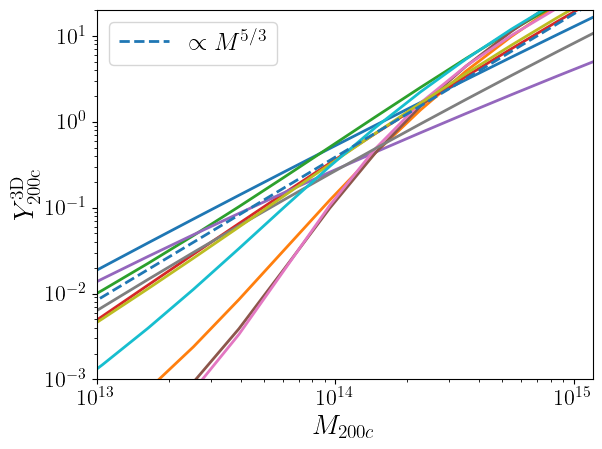

In [7]:
pl.figure()
for ji in range(len(indsel)):
    pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
pl.plot(M_array, 1.8e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-3, 2e1)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()



In [13]:
# np.save('Y_model_all.npz',Y_model_all_samp)
Y_model_all_samp = np.array(Y_model_all_samp)



In [18]:
# Y_model_all_samp.shape
Ymin = np.percentile(Y_model_all_samp, 16, axis=0)
Ymax = np.percentile(Y_model_all_samp, 84, axis=0)


In [19]:
Ymin


array([3.49149600e-07, 7.43968223e-07, 1.47319114e-06, 2.76341993e-06,
       5.12153539e-06, 9.68322375e-06, 1.86207291e-05, 3.71945839e-05,
       8.34853237e-05, 2.20928817e-04, 7.36346869e-04, 2.78776877e-03,
       1.17022969e-02, 5.35086578e-02, 1.86740339e-01, 5.05589227e-01,
       1.15064137e+00, 2.38566765e+00, 5.17808615e+00, 1.02470765e+01,
       1.89989716e+01, 3.41610104e+01])

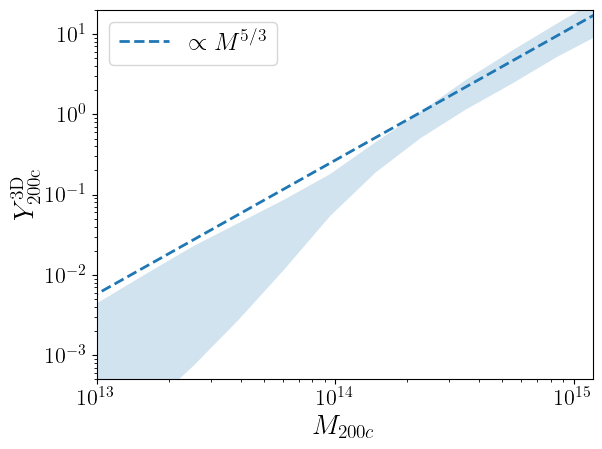

In [23]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
pl.fill_between(M_array, Ymin, Ymax, alpha=0.2)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
pl.plot(M_array, 1.25e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(5e-4, 2e1)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()

